# Notebook 04: Feature Engineering

## Introduction
Before training our machine learning models, we need to extract and construct predictors that can help capture patterns in our data. In this notebook, we perform the Feature Engineering phase. 

Using the cleaned datasets from the preprocessing phase, we will construct:
1. **Date Features**: Year, Month, WeekOfYear, Quarter, Is_Q4, and Is_Holiday_Month.
2. **Lag Features**: Weekly sales lags (1, 2, 3, 4, 8, 12, 26, and 52 weeks) to represent historical performance.
3. **Rolling Features**: 4, 12, 26, and 52-week moving averages (rolling_mean) and standard deviations (rolling_std).
4. **Holiday Features**: Specific binary indicators (Is_SuperBowl, Is_LaborDay, Is_Thanksgiving, Is_Christmas).
5. **Markdown Features**: Total promotional markdown values (MarkDown_Total), binary indicator (Has_MarkDown), average (MarkDown_Avg), and maximum (MarkDown_Max).
6. **Store and Department Features**: Store average sales (Store_Avg_Sales), Department average sales (Dept_Avg_Sales), Store-Department average sales (Store_Dept_Avg_Sales), Store size (Size), and Store type encoding (Type_Encoded).
7. **Interaction Features**: Holiday_MarkDown, Q4_Holiday, and Size_MarkDown.

### The Lag Propagation Methodology
A critical challenge in time-series forecasting is computing lag and rolling window features for the **test set**. Since the test set has no target `Weekly_Sales` records, any lag feature computed on the test set in isolation would result in missing values (`NaN`). 

To address this, we **concatenate** the cleaned training and test dataframes, compute our features across the entire timeline, and then split them back. Concatenating train and test allows the early test records to use the latest available historical sales from the training data. However, because future test sales are unknown, later test lag values may require recursive forecasting or model-specific handling.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Add project root to path
sys.path.append(os.path.abspath('..'))

## 1. Load Cleaned Datasets
We load the preprocessed training and test datasets.

In [2]:
from src import config

train_df = pd.read_csv(config.TRAIN_CLEANED_PATH)
test_df = pd.read_csv(config.TEST_CLEANED_PATH)

print("Cleaned Train Shape:", train_df.shape)
print("Cleaned Test Shape:", test_df.shape)

Cleaned Train Shape: (421570, 17)
Cleaned Test Shape: (115064, 15)


## 2. Execute Feature Engineering Pipeline
We convert the date columns to datetime objects, create a temporary target column on the test set, concatenate the dataframes, and pass them to our modular feature engineering pipeline `build_features_pipeline`.

In [3]:
from src.feature_engineering import build_features_pipeline

# Ensure Date is parsed as datetime
train_df['Date'] = pd.to_datetime(train_df['Date'])
test_df['Date'] = pd.to_datetime(test_df['Date'])

# Set temporary Weekly_Sales column in test to NaN
test_df['Weekly_Sales'] = np.nan

# Concatenate datasets
combined_df = pd.concat([train_df, test_df], ignore_index=True)

# Build features
print("Engineering features across the combined dataset...")
combined_featured = build_features_pipeline(combined_df)

# Split back based on Weekly_Sales
train_features = combined_featured[combined_featured['Weekly_Sales'].notnull()].copy()
test_features = combined_featured[combined_featured['Weekly_Sales'].isnull()].copy()

# Drop the temporary column and Weekly_Sales_Original from test
test_features = test_features.drop(columns=['Weekly_Sales', 'Weekly_Sales_Original'], errors='ignore')

print("Train Features Shape:", train_features.shape)
print("Test Features Shape:", test_features.shape)

Engineering features across the combined dataset...
Train Features Shape: (421570, 53)
Test Features Shape: (115064, 51)


### 2.1 Before and After Shape Comparison
We verify that our pipeline successfully added the new engineered features to the datasets by checking the change in the number of columns.

In [4]:
print("Original Train Shape:", train_df.shape)
print("Feature Engineered Train Shape:", train_features.shape)

print("Original Test Shape:", test_df.shape)
print("Feature Engineered Test Shape:", test_features.shape)

print("New features created:", train_features.shape[1] - train_df.shape[1])

Original Train Shape: (421570, 17)
Feature Engineered Train Shape: (421570, 53)
Original Test Shape: (115064, 16)
Feature Engineered Test Shape: (115064, 51)
New features created: 36


### 2.2 Feature Summary Table
Let's review the groups of new features generated by our pipeline.

In [5]:
feature_groups = {
    "Date Features": ["Year", "Month", "WeekOfYear", "Quarter", "Is_Q4", "Is_Holiday_Month"],
    "Lag Features": [col for col in train_features.columns if "lag" in col],
    "Rolling Features": [col for col in train_features.columns if "rolling" in col],
    "Holiday Features": ["Is_SuperBowl", "Is_LaborDay", "Is_Thanksgiving", "Is_Christmas"],
    "Markdown Features": ["MarkDown_Total", "Has_MarkDown", "MarkDown_Avg", "MarkDown_Max"],
    "Interaction Features": ["Holiday_MarkDown", "Q4_Holiday", "Size_MarkDown"]
}

for group, features in feature_groups.items():
    print(f"\n{group}:")
    print(features)


Date Features:
['Year', 'Month', 'WeekOfYear', 'Quarter', 'Is_Q4', 'Is_Holiday_Month']

Lag Features:
['Weekly_Sales_lag_1', 'Weekly_Sales_lag_2', 'Weekly_Sales_lag_3', 'Weekly_Sales_lag_4', 'Weekly_Sales_lag_8', 'Weekly_Sales_lag_12', 'Weekly_Sales_lag_26', 'Weekly_Sales_lag_52']

Rolling Features:
['rolling_mean_4', 'rolling_mean_12', 'rolling_mean_26', 'rolling_mean_52', 'rolling_std_4', 'rolling_std_12', 'rolling_std_52']

Holiday Features:
['Is_SuperBowl', 'Is_LaborDay', 'Is_Thanksgiving', 'Is_Christmas']

Markdown Features:
['MarkDown_Total', 'Has_MarkDown', 'MarkDown_Avg', 'MarkDown_Max']

Interaction Features:
['Holiday_MarkDown', 'Q4_Holiday', 'Size_MarkDown']


## 3. Visualizing Lags and Rolling Windows
Let's inspect a single store/department group to verify that the lags and rolling metrics align correctly. We plot a 6-month subset of actual sales against the 1-week and 2-week lags, as well as 4-week and 12-week moving averages (rolling means). 

* **Lags:** We expect the lag lines to be exact shifted copies of the actual sales line.
* **Rolling Means:** We expect the rolling means to smooth out short-term fluctuations and capture local moving trends.

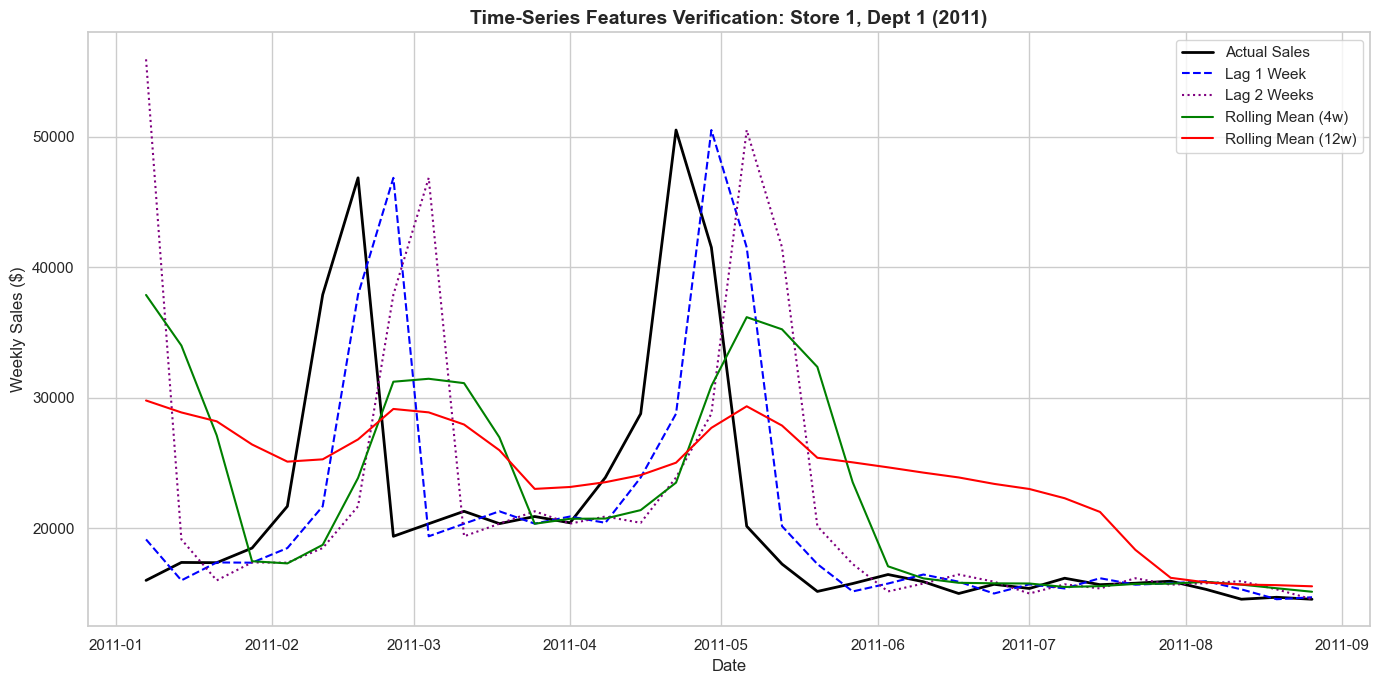

In [6]:
# Select sample store & department
sample = train_features[(train_features['Store'] == 1) & (train_features['Dept'] == 1)].sort_values('Date')
sample_sub = sample[(sample['Date'] >= '2011-01-01') & (sample['Date'] <= '2011-08-31')]

plt.figure(figsize=(14, 7))
plt.plot(sample_sub['Date'], sample_sub['Weekly_Sales'], label='Actual Sales', color='black', linewidth=2)
plt.plot(sample_sub['Date'], sample_sub['Weekly_Sales_lag_1'], label='Lag 1 Week', linestyle='--', color='blue')
plt.plot(sample_sub['Date'], sample_sub['Weekly_Sales_lag_2'], label='Lag 2 Weeks', linestyle=':', color='purple')
plt.plot(sample_sub['Date'], sample_sub['rolling_mean_4'], label='Rolling Mean (4w)', color='green')
plt.plot(sample_sub['Date'], sample_sub['rolling_mean_12'], label='Rolling Mean (12w)', color='red')

plt.title('Time-Series Features Verification: Store 1, Dept 1 (2011)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Weekly Sales ($)', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 4. Data Leakage Check
The lag and rolling features are calculated using previous sales values only. The current week's `Weekly_Sales` value is not used when creating lag or rolling features, which helps prevent data leakage. 

Let's print the actual sales side-by-side with `Weekly_Sales_lag_1` and `rolling_mean_4` to visually inspect that the historical calculations look back and do not include the current week's sales.

In [7]:
sample_check = train_features[
    (train_features["Store"] == 1) & 
    (train_features["Dept"] == 1)
].sort_values("Date")

sample_check[[
    "Date", 
    "Weekly_Sales", 
    "Weekly_Sales_lag_1", 
    "rolling_mean_4"
]].head(10)

,Date,Weekly_Sales,Weekly_Sales_lag_1,rolling_mean_4
0,2010-02-05,24924.50,NaN,NaN
1,2010-02-12,46039.49,24924.50,24924.500000
2,2010-02-19,41595.55,46039.49,35481.995000
3,2010-02-26,19403.54,41595.55,37519.846667
4,2010-03-05,21827.90,19403.54,32990.770000
5,2010-03-12,21043.39,21827.90,32216.620000
6,2010-03-19,22136.64,21043.39,25967.595000
7,2010-03-26,26229.21,22136.64,21102.867500
8,2010-04-02,57258.43,26229.21,22809.285000
9,2010-04-09,42960.91,57258.43,31666.917500


## 5. Visualizing Specific Holiday Impacts
EDA notebook showed that sales spikes are highly correlated with holiday weeks. Here, we plot average weekly sales for regular weeks compared to each of the four mapped holiday indicators (`Is_SuperBowl`, `Is_LaborDay`, `Is_Thanksgiving`, `Is_Christmas`). This justifies why mapping these holidays separately is highly informative.

C:\Users\rahul\AppData\Local\Temp\ipykernel_11832\3240713401.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=categories, y=avg_sales, palette='viridis')


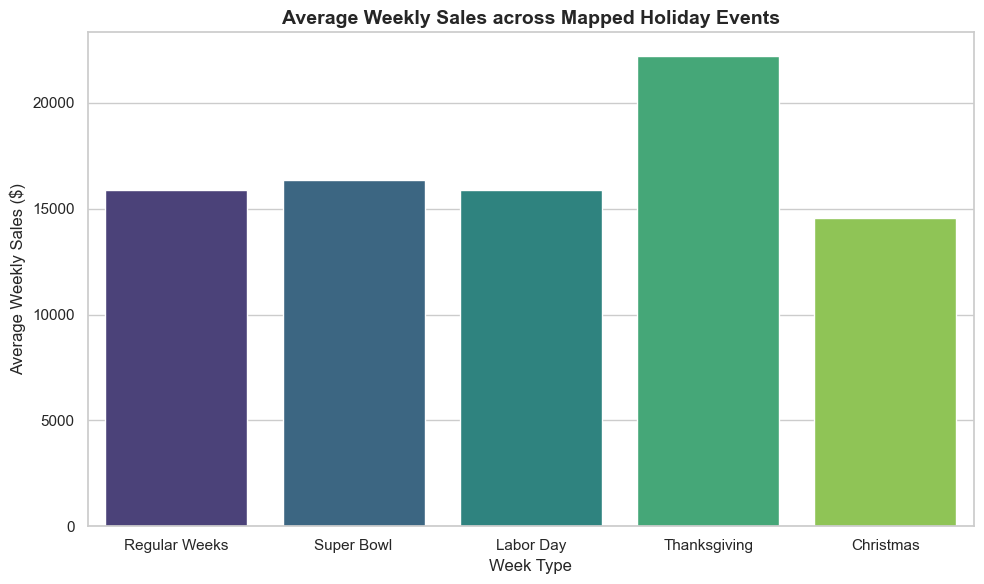

In [8]:
holidays = ['Is_SuperBowl', 'Is_LaborDay', 'Is_Thanksgiving', 'Is_Christmas']
avg_sales = []

# Baseline sales on non-holiday weeks
avg_sales.append(train_features[train_features['IsHoliday'] == False]['Weekly_Sales'].mean())

# Sales on each specific holiday
for h in holidays:
    avg_sales.append(train_features[train_features[h] == 1]['Weekly_Sales'].mean())

categories = ['Regular Weeks', 'Super Bowl', 'Labor Day', 'Thanksgiving', 'Christmas']

plt.figure(figsize=(10, 6))
sns.barplot(x=categories, y=avg_sales, palette='viridis')
plt.title('Average Weekly Sales across Mapped Holiday Events', fontsize=14, fontweight='bold')
plt.xlabel('Week Type', fontsize=12)
plt.ylabel('Average Weekly Sales ($)', fontsize=12)
plt.tight_layout()
plt.show()

## 6. Interaction Features Analysis
We check the impact of our engineered interaction features. Below, we compare average sales for standard weeks, general Q4 weeks without holidays, general holidays outside of Q4, and the compound Q4 holidays (`Q4_Holiday`). Combining Q4 and holiday indicators captures the synergistic impact of holiday shopping.

C:\Users\rahul\AppData\Local\Temp\ipykernel_11832\749853889.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=sales_vals, palette='magma')


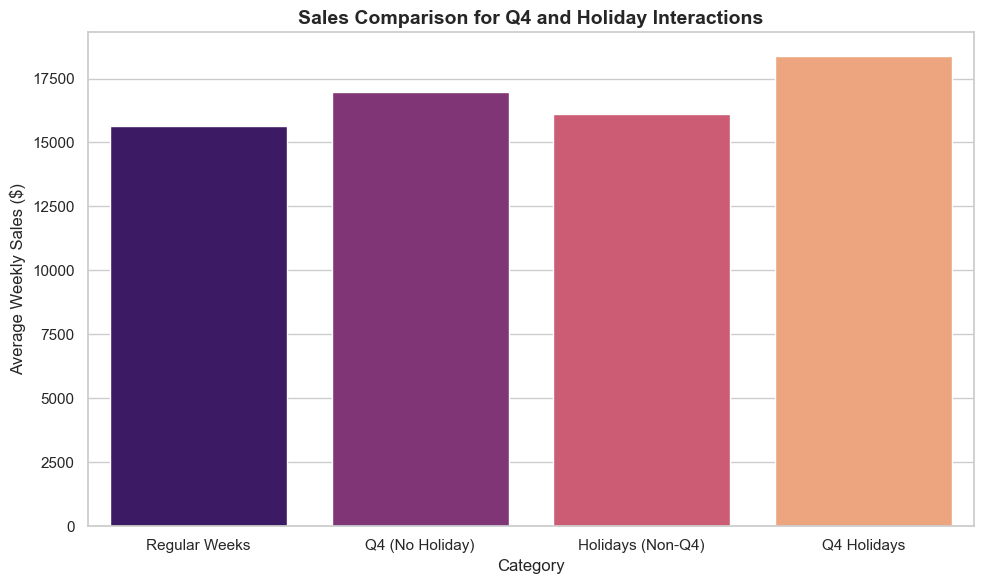

In [9]:
no_q4_no_holiday = train_features[(train_features['Is_Q4'] == 0) & (train_features['IsHoliday'] == 0)]['Weekly_Sales'].mean()
q4_no_holiday = train_features[(train_features['Is_Q4'] == 1) & (train_features['IsHoliday'] == 0)]['Weekly_Sales'].mean()
holiday_no_q4 = train_features[(train_features['Is_Q4'] == 0) & (train_features['IsHoliday'] == 1)]['Weekly_Sales'].mean()
q4_holiday = train_features[train_features['Q4_Holiday'] == 1]['Weekly_Sales'].mean()

labels = ['Regular Weeks', 'Q4 (No Holiday)', 'Holidays (Non-Q4)', 'Q4 Holidays']
sales_vals = [no_q4_no_holiday, q4_no_holiday, holiday_no_q4, q4_holiday]

plt.figure(figsize=(10, 6))
sns.barplot(x=labels, y=sales_vals, palette='magma')
plt.title('Sales Comparison for Q4 and Holiday Interactions', fontsize=14, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Average Weekly Sales ($)', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Feature Distribution Plots
To understand if the newly engineered features contain extreme values or skewed distributions, we plot histograms with kernel density estimates (KDE) for a selection of engineered variables.

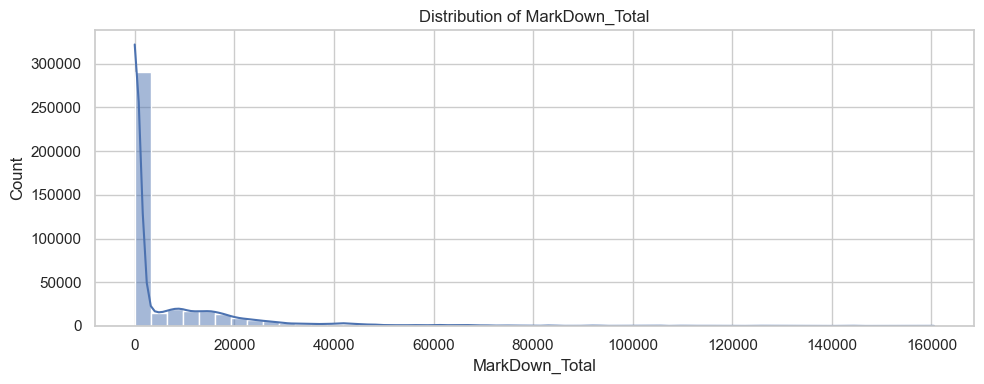

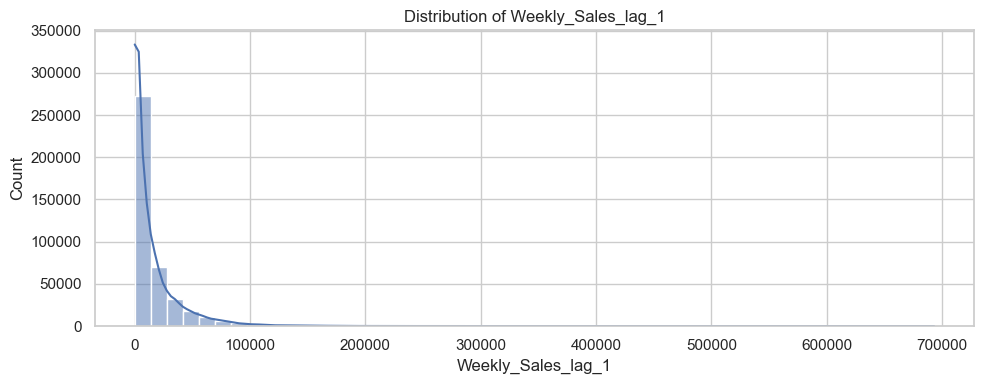

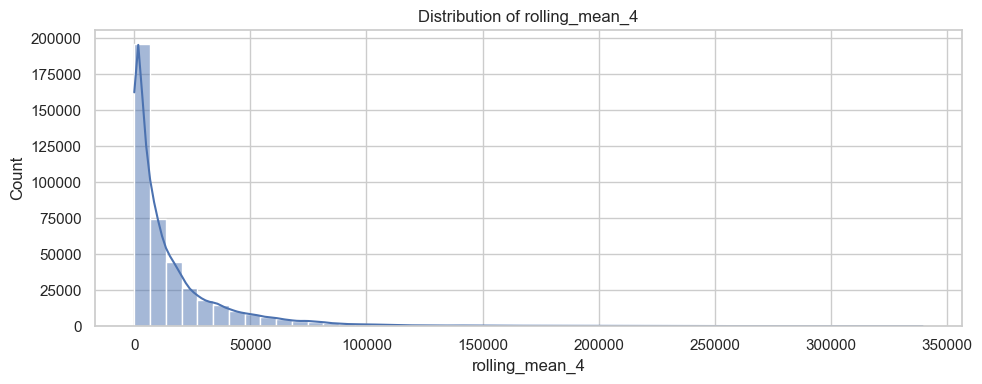

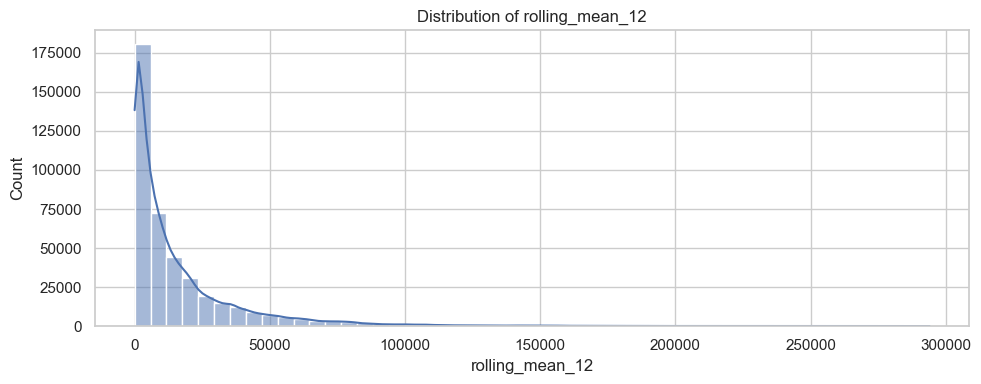

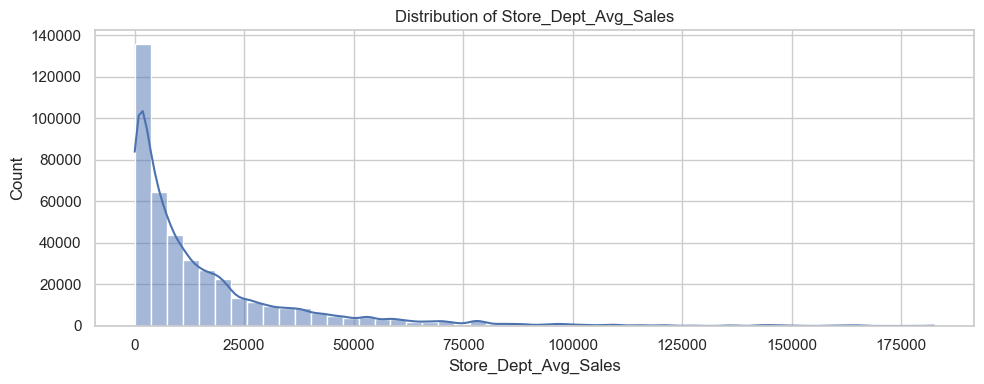

In [10]:
selected_features = [
    "MarkDown_Total",
    "Weekly_Sales_lag_1",
    "rolling_mean_4",
    "rolling_mean_12",
    "Store_Dept_Avg_Sales"
]

for col in selected_features:
    if col in train_features.columns:
        plt.figure(figsize=(10, 4))
        sns.histplot(train_features[col], bins=50, kde=True)
        plt.title(f"Distribution of {col}")
        plt.tight_layout()
        plt.show()

## 8. Feature Correlation with Target
We calculate and plot the Pearson correlation coefficients between `Weekly_Sales` and our newly engineered features. To prevent any KeyError, we dynamically filter the features to check to ensure they are present in the dataframe.

C:\Users\rahul\AppData\Local\Temp\ipykernel_11832\2927023736.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations.values, y=correlations.index, palette='coolwarm')


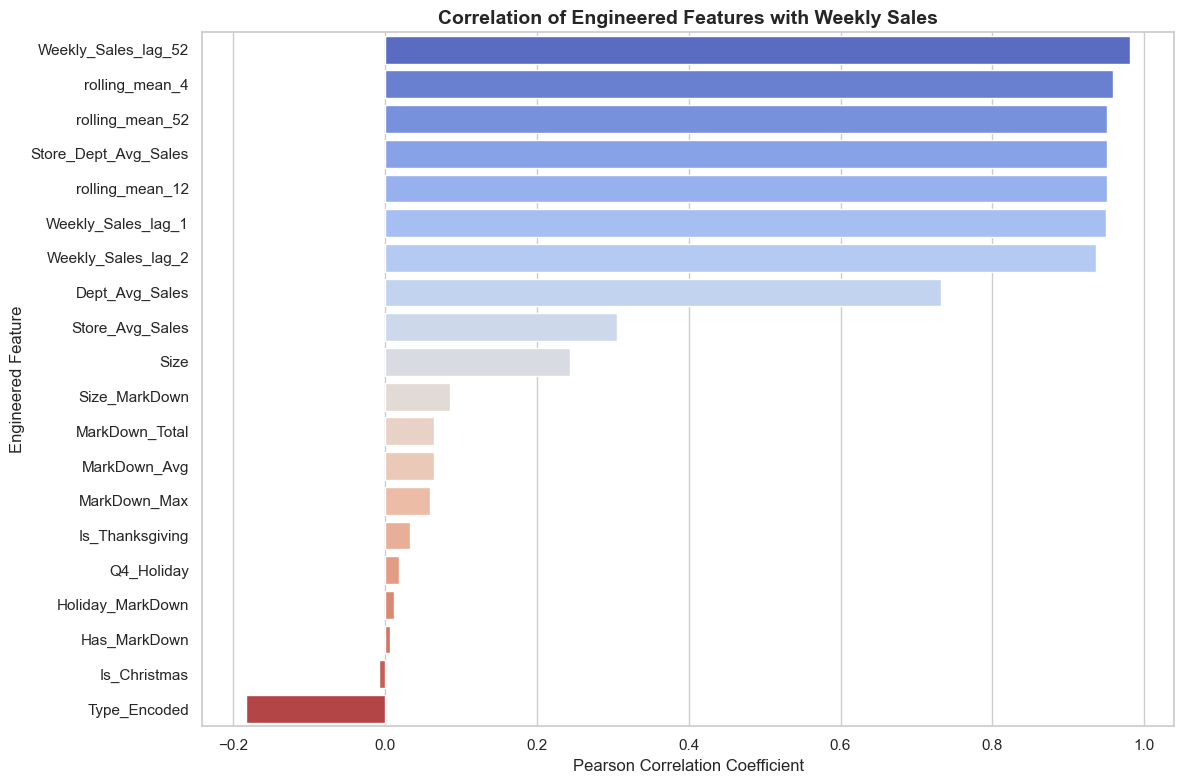

In [11]:
features_to_check = [
    'Size', 'Type_Encoded', 'MarkDown_Total', 'Has_MarkDown', 'MarkDown_Avg', 'MarkDown_Max',
    'Weekly_Sales_lag_1', 'Weekly_Sales_lag_2', 'Weekly_Sales_lag_52',
    'rolling_mean_4', 'rolling_mean_12', 'rolling_mean_52',
    'Store_Avg_Sales', 'Dept_Avg_Sales', 'Store_Dept_Avg_Sales',
    'Is_Thanksgiving', 'Is_Christmas', 'Holiday_MarkDown', 'Q4_Holiday', 'Size_MarkDown'
]

# Safe filter to ensure columns exist in dataframe
features_to_check = [col for col in features_to_check if col in train_features.columns]

correlations = train_features[features_to_check].corrwith(train_features['Weekly_Sales']).sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=correlations.values, y=correlations.index, palette='coolwarm')
plt.title('Correlation of Engineered Features with Weekly Sales', fontsize=14, fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient', fontsize=12)
plt.ylabel('Engineered Feature', fontsize=12)
plt.tight_layout()
plt.show()

## 9. Handle Missing Values in Engineered Columns
Because lag and rolling window features require historical records, the first few weeks of each store-department series will contain missing values (`NaN`). For example, a 52-week lag will be `NaN` for the first year of data. 

To keep all other columns unmodified, we selectively locate the historical columns (lag and rolling window variables) and fill only their missing entries with `0.0`.

In [12]:
# Identify columns with missing values (lags and rolling statistics)
lag_rolling_cols = [
    col for col in train_features.columns
    if "lag" in col or "rolling" in col
]

# Impute missing entries with 0.0
train_features[lag_rolling_cols] = train_features[lag_rolling_cols].fillna(0.0)
test_features[lag_rolling_cols] = test_features[lag_rolling_cols].fillna(0.0)

print("Remaining NaNs in train features:", train_features.isnull().sum().sum())
print("Remaining NaNs in test features:", test_features.isnull().sum().sum())

Remaining NaNs in train features: 0
Remaining NaNs in test features: 0


## 10. Dataset Validation
Before saving the datasets, we verify their contents, missing value status, date range boundaries, and dimensions. This validation shows that the final dataset is complete and ready for modelling.

In [13]:
print("Missing values in train features:")
print(train_features.isnull().sum()[train_features.isnull().sum() > 0])

print("\nMissing values in test features:")
print(test_features.isnull().sum()[test_features.isnull().sum() > 0])

print("\nTrain date range:", train_features["Date"].min().strftime('%Y-%m-%d'), "to", train_features["Date"].max().strftime('%Y-%m-%d'))
print("Test date range:", test_features["Date"].min().strftime('%Y-%m-%d'), "to", test_features["Date"].max().strftime('%Y-%m-%d'))

print("\nTrain shape:", train_features.shape)
print("Test shape:", test_features.shape)

Missing values in train features:
Series([], dtype: int64)

Missing values in test features:
Series([], dtype: int64)

Train date range: 2010-02-05 to 2012-10-26
Test date range: 2012-11-02 to 2013-07-26

Train shape: (421570, 53)
Test shape: (115064, 51)


## 11. Final Feature List for Modelling
To feed the dataset into our machine learning models, we drop variables that are redundant, textual, or cannot be passed directly into numeric predictors (such as raw string dates or original text-type categorical categories). The list below represents the exact model features list.

In [14]:
drop_cols = ["Date", "Weekly_Sales", "Weekly_Sales_Original", "Type"]

model_features = [
    col for col in train_features.columns 
    if col not in drop_cols
]

print("Number of model features:", len(model_features))
print(model_features)

Number of model features: 49
['Store', 'Dept', 'IsHoliday', 'Size', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Year', 'Month', 'WeekOfYear', 'Quarter', 'Is_Q4', 'Is_Holiday_Month', 'Is_SuperBowl', 'Is_LaborDay', 'Is_Thanksgiving', 'Is_Christmas', 'MarkDown_Total', 'Has_MarkDown', 'MarkDown_Avg', 'MarkDown_Max', 'Weekly_Sales_lag_1', 'Weekly_Sales_lag_2', 'Weekly_Sales_lag_3', 'Weekly_Sales_lag_4', 'Weekly_Sales_lag_8', 'Weekly_Sales_lag_12', 'Weekly_Sales_lag_26', 'Weekly_Sales_lag_52', 'rolling_mean_4', 'rolling_mean_12', 'rolling_mean_26', 'rolling_mean_52', 'rolling_std_4', 'rolling_std_12', 'rolling_std_52', 'Store_Avg_Sales', 'Dept_Avg_Sales', 'Store_Dept_Avg_Sales', 'Type_Encoded', 'Holiday_MarkDown', 'Q4_Holiday', 'Size_MarkDown']


### Important Note on Test Lag Limitations
Since the test dataset does not contain `Weekly_Sales` values, lag and rolling features for the test set can only use historical sales available from the training period. For later test weeks, recursive forecasting or model-specific handling may be required.

### Important Note on Target Leakage during Validation
For final model validation, when splitting the training data into train and validation periods, the historical averages (`Store_Avg_Sales`, `Dept_Avg_Sales`, and `Store_Dept_Avg_Sales`) must be computed using only the training portion, not the validation portion. Calculating these averages across the entire training period before splitting will leak the validation target values into the validation features, causing target leakage.

## 12. Save Feature-Engineered Datasets
We save the finalized features as `train_features.csv` and `test_features.csv` in `data/processed/` for downstream modeling.

In [15]:
train_features.to_csv(config.TRAIN_FEATURES_PATH, index=False)
test_features.to_csv(config.TEST_FEATURES_PATH, index=False)

print(f"Saved Train Features ({train_features.shape}) to {config.TRAIN_FEATURES_PATH}")
print(f"Saved Test Features ({test_features.shape}) to {config.TEST_FEATURES_PATH}")

Saved Train Features ((421570, 53)) to D:\University Of Galway\CT5108 Data Analytics Project\sales-forecasting-inventory-optimization\data\processed\train_features.csv
Saved Test Features ((115064, 51)) to D:\University Of Galway\CT5108 Data Analytics Project\sales-forecasting-inventory-optimization\data\processed\test_features.csv
